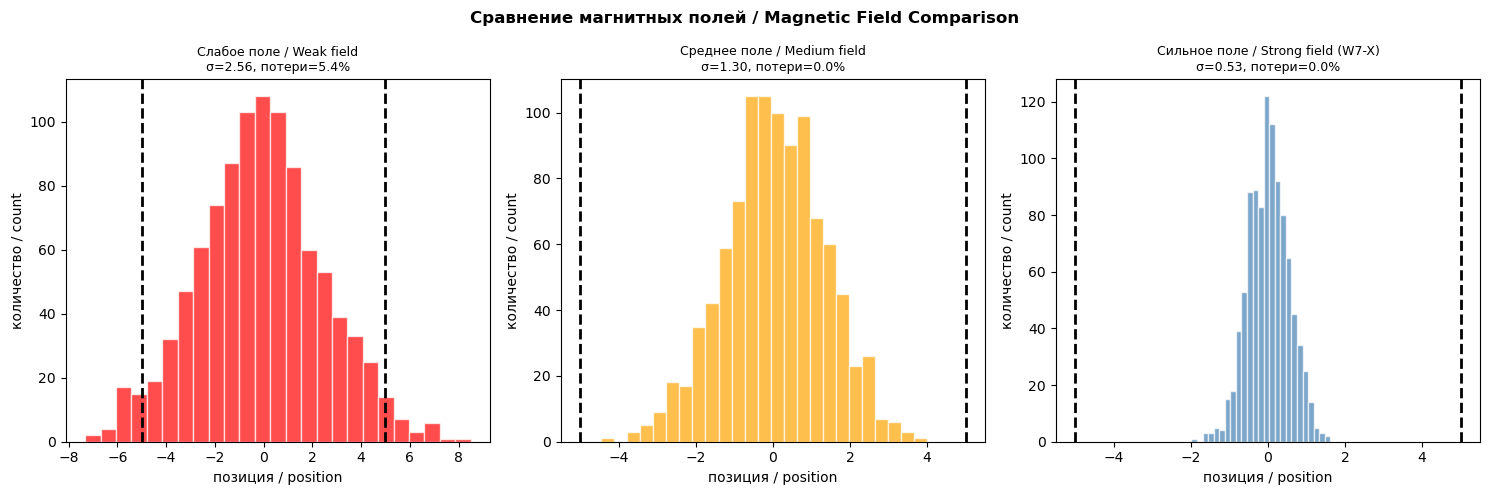


Результаты / Results:
Слабое поле / Weak field: потери / lost = 5.4%
Среднее поле / Medium field: потери / lost = 0.0%
Сильное поле / Strong field (W7-X): потери / lost = 0.0%


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# три разных магнитных поля / three different magnetic fields
fields = {
    'Слабое поле / Weak field':   1.0,
    'Среднее поле / Medium field': 0.5,
    'Сильное поле / Strong field (W7-X)': 0.2
}

wall = 5
steps = 20
particles = 1000

results = {}

for field_name, step_size in fields.items():
    positions = np.random.uniform(-step_size, step_size, 
                                   size=(particles, steps))
    final = np.sum(positions, axis=1)
    lost = np.sum(np.abs(final) > wall)
    results[field_name] = {
        'final': final,
        'lost': lost,
        'sigma': np.std(final),
        'loss_percent': round(lost/particles*100, 1)
    }

# график / plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['red', 'orange', 'steelblue']

for ax, (name, data), color in zip(axes, results.items(), colors):
    ax.hist(data['final'], bins=25, color=color, 
            alpha=0.7, edgecolor='white')
    ax.axvline(x=wall, color='black', linewidth=2, 
               linestyle='--')
    ax.axvline(x=-wall, color='black', linewidth=2, 
               linestyle='--')
    ax.set_title(f'{name}\nσ={data["sigma"]:.2f}, '
                 f'потери={data["loss_percent"]}%', 
                 fontsize=9)
    ax.set_xlabel('позиция / position')
    ax.set_ylabel('количество / count')

plt.suptitle('Сравнение магнитных полей / Magnetic Field Comparison', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nРезультаты / Results:")
for name, data in results.items():
    print(f"{name}: потери / lost = {data['loss_percent']}%")